In [31]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

from algorithm.cli.count import main as count_main

In [33]:
def plot_elapsed_time_over_length(
    lengths: list[int],
    rankings: list[list[tuple[str, list[float]]]],
):
    """
    Plot the elapsed time of each counting method over different string lengths
    using sns lineplot. The x-axis represents the string lengths, and the y-axis represents elapsed time in seconds.
    with 95% confidence intervals. Each method should have a different color and a legend indicating the method names.
    """
    # Prepare data for plotting
    data = []
    for length, ranking in zip(lengths, rankings):
        for method_name, times in ranking:
            for time in times:
                data.append(
                    {
                        "Length": length,
                        "Method": method_name,
                        "Elapsed Time": time,
                    }
                )

    # Create a DataFrame for plotting
    import pandas as pd

    df = pd.DataFrame(data)

    # Plot using seaborn
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x="Length", y="Elapsed Time", hue="Method", marker="o")
    plt.title("Elapsed Time of Counting Methods Over String Lengths")
    plt.xlabel("String Length")
    plt.ylabel("Elapsed Time (seconds)")

    # log log
    plt.xscale("log")
    plt.yscale("log")

    plt.legend(title="Counting Method")
    plt.grid(True)
    plt.show()

In [34]:
num_iter = 100

lengths = [50, 1e2, 1e3, 1e4, 1e5, 1e6]
elapsed_times = []
for length in lengths:
    results = count_main(
        n_iter=num_iter,
        string_length=int(length),
    )
    elapsed_times.append(results)

KeyboardInterrupt: 

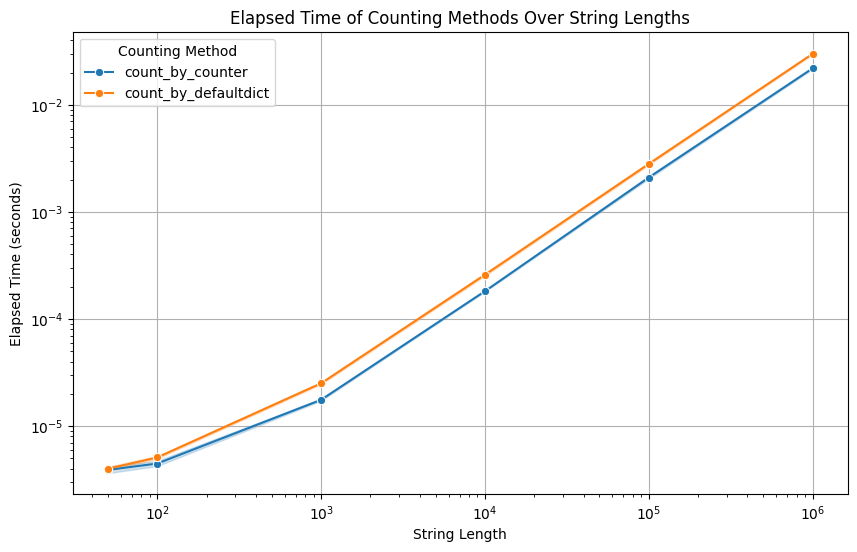

In [ ]:
plot_elapsed_time_over_length(
    lengths=lengths,
    rankings=elapsed_times,
)